In [1]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
def preprocess(img_path, filter_type='gaussian'):
    img_bgr = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if filter_type == 'gaussian':
        img_filtered = cv2.GaussianBlur(img_gray, (3,3), 0)
    elif filter_type == 'median':
        img_filtered = cv2.medianBlur(img_gray, 3)
    elif filter_type == 'bilateral':
        img_filtered = cv2.bilateralFilter(img_gray, 9, 75, 75)
    else:
        img_filtered = img_gray

    return img_bgr, img_filtered

In [4]:
def match_features(img1_path, img2_path, method='SIFT', ratio_thresh=0.7, filter_type='gaussian'):
    img1_color, img1_pre = preprocess(img1_path, filter_type)
    img2_color, img2_pre = preprocess(img2_path, filter_type)

    if method == 'SIFT':
        detector = cv2.SIFT.create()
    elif method == 'AKAZE':
        detector = cv2.AKAZE_create()
    else:
        detector = cv2.ORB_create()

    kp1, des1 = detector.detectAndCompute(img1_pre, None)
    kp2, des2 = detector.detectAndCompute(img2_pre, None)

    des1 = np.float32(des1)
    des2 = np.float32(des2)

    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    matches = flann.knnMatch(des1, des2, k=2)

    img1_rgb = cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB)

    best_matches = [m for m, n in matches if m.distance < ratio_thresh * n.distance]

    img_res = cv2.drawMatches(
        img1_rgb, kp1,
        img2_rgb, kp2,
        best_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return img_res, len(best_matches)


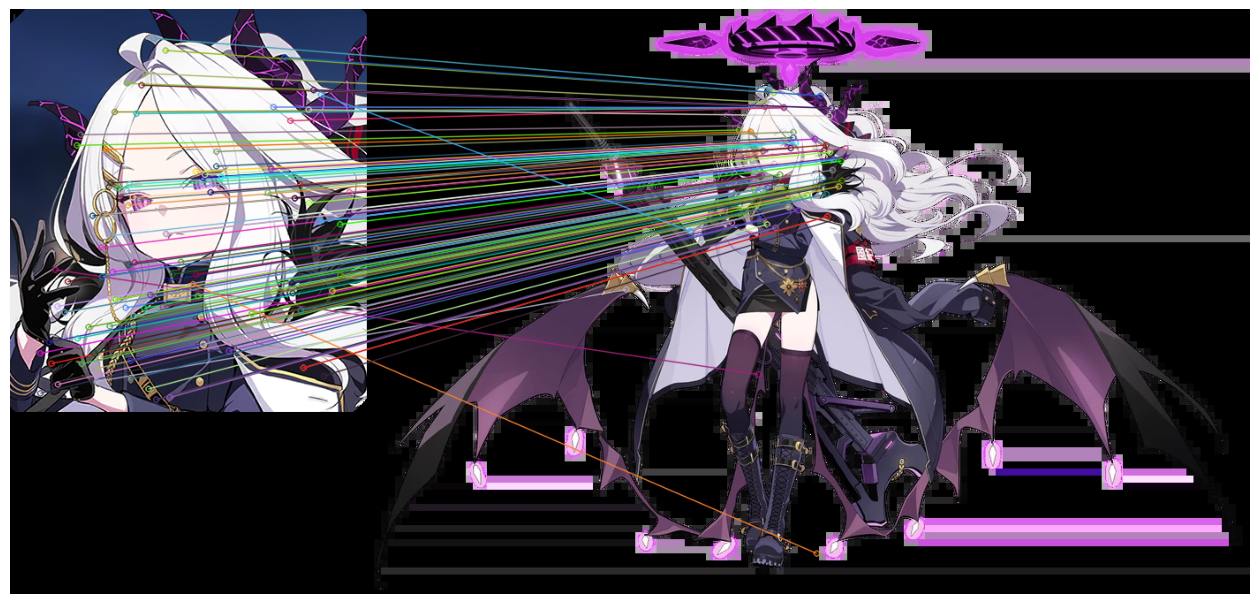

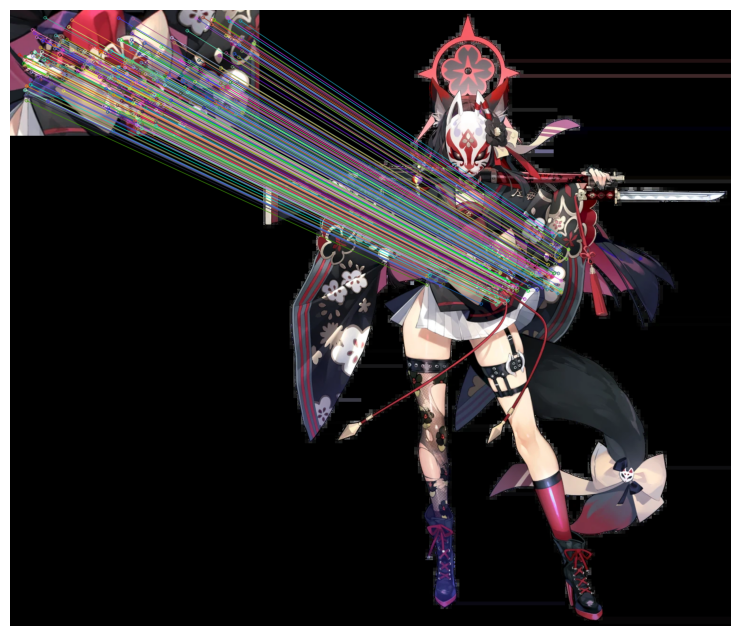

In [7]:
target_dir = 'target'
source_dir = 'source'

target_img = glob.glob(os.path.join(target_dir, '*.png'))
source_img = glob.glob(os.path.join(source_dir, '*.png'))

selected_method = 'SIFT'
selected_filter = 'gaussian'
ratios = [0.7]

for target_path in target_img:
    best_match_count = 0
    best_image = None
    best_score = 0.0
    for source_path in source_img:
        for ratio in ratios:
            result, match_count = match_features(target_path, source_path, method=selected_method, ratio_thresh=ratio, filter_type=selected_filter)
            if match_count > best_match_count:
                best_match_count = match_count
                best_image = result
                best_score = float(match_count)

    if result is not None:
        plt.figure(figsize=(16,8))
        plt.axis('off')
        plt.imshow(best_image)
        plt.show()